# Week 1-2: Probability Through Experimentation

## Can We Predict Randomness?

Last week, you built your programming toolkit. This week, we're going to use it to explore one of mathematics' most beautiful ideas: **probability**.

Here's the paradox we'll investigate: Individual random events are completely unpredictable, yet patterns emerge when we observe them in large numbers. A single coin flip is pure chance, but flip a coin 1,000 times and you'll get very close to 500 heads.

How does order emerge from chaos?

Let's find out through experimentation.

---

## Part 1: The Random Walk

Imagine someone who's had a bit too much to drink walking along a straight path. At each step, they randomly move either left or right. Where will they end up?

This "random walk" is one of the most important concepts in probability, with applications in:
- Stock market modeling
- Physics (Brownian motion)
- Biology (molecular diffusion)
- Computer science (algorithm analysis)

Let's simulate it!

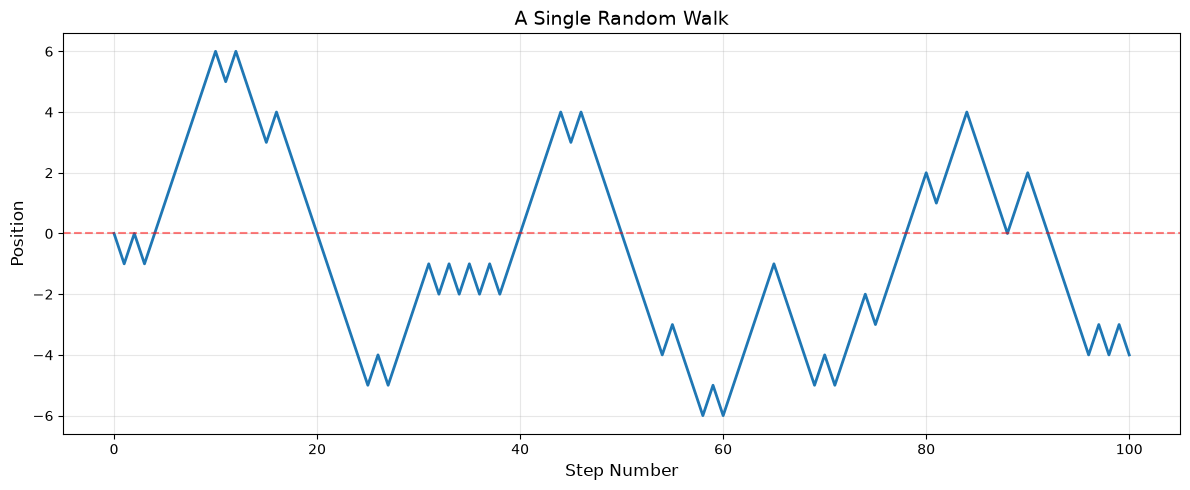

Started at: 0
Ended at: -4
Distance traveled: 4 steps from start


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def random_walk_1d(steps):
    """
    Simulate a 1D random walk.
    At each step, move left (-1) or right (+1) with equal probability.
    """
    position = 0
    positions = [position]
    
    for _ in range(steps):
        # Flip a coin: -1 or +1
        step = np.random.choice([-1, 1])
        position += step
        positions.append(position)
    
    return positions

# Run and visualize
steps = 100
walk = random_walk_1d(steps)

plt.figure(figsize=(12, 5))
plt.plot(walk, linewidth=2)
plt.xlabel('Step Number', fontsize=12)
plt.ylabel('Position', fontsize=12)
plt.title('A Single Random Walk', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Started at: 0")
print(f"Ended at: {walk[-1]}")
print(f"Distance traveled: {abs(walk[-1])} steps from start")

### Exploration Questions

Run the cell above multiple times. What do you notice?

1. Does the walker ever return to 0?
2. How far from 0 do they typically end up?
3. Does the walk always look the same?

**Challenge:** Modify the code so the walker is twice as likely to step right. What changes?

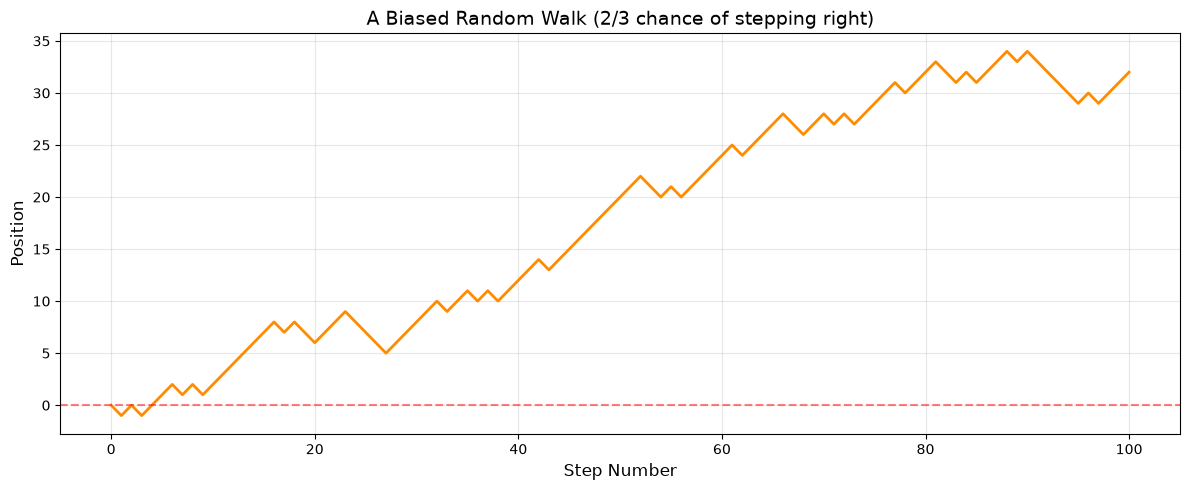

Ended at: 32
With a rightward bias, the walk drifts upward instead of hovering near 0.


In [2]:
# Your biased random walk here!
# Hint: Use np.random.choice([-1, 1], p=[1/3, 2/3])

def biased_random_walk_1d(steps, p_right=2/3):
    """A random walk where a step right is more likely than a step left."""
    position = 0
    positions = [position]

    for _ in range(steps):
        step = np.random.choice([-1, 1], p=[1 - p_right, p_right])
        position += step
        positions.append(position)

    return positions

biased_walk = biased_random_walk_1d(100)

plt.figure(figsize=(12, 5))
plt.plot(biased_walk, linewidth=2, color='darkorange')
plt.xlabel('Step Number', fontsize=12)
plt.ylabel('Position', fontsize=12)
plt.title('A Biased Random Walk (2/3 chance of stepping right)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Ended at: {biased_walk[-1]}")
print("With a rightward bias, the walk drifts upward instead of hovering near 0.")


---

## Part 2: Multiple Walks - Patterns Emerge

One walk tells us nothing. But what about 100 walks? Let's find out:

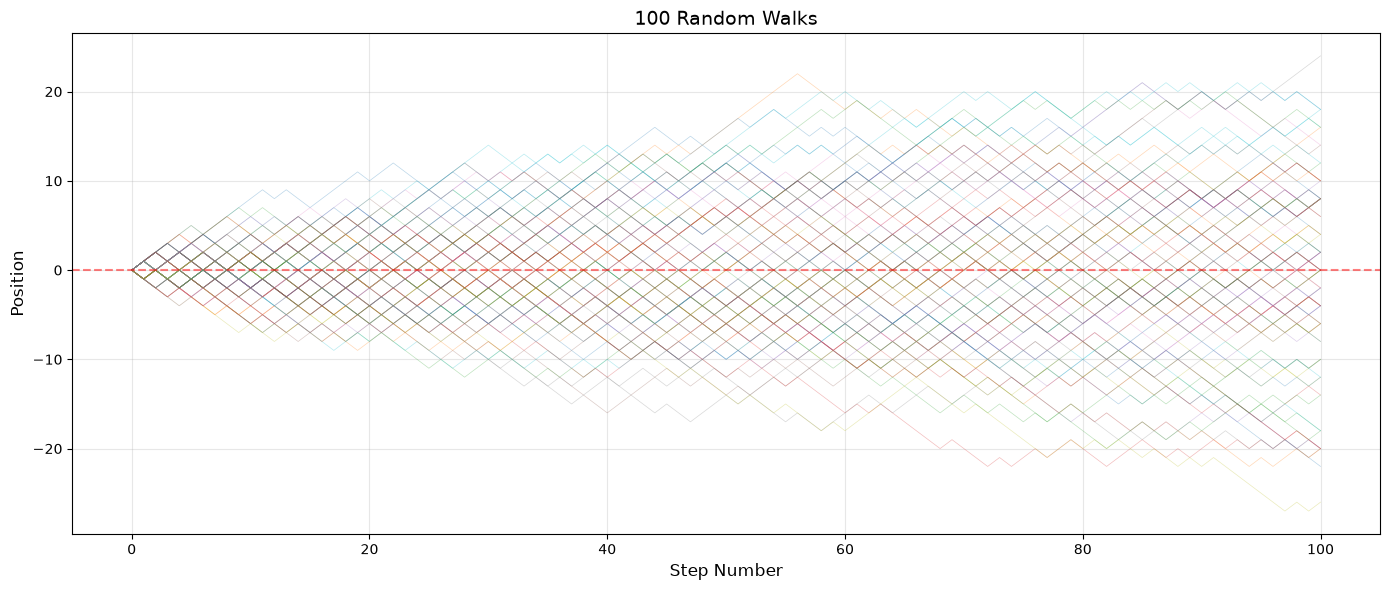

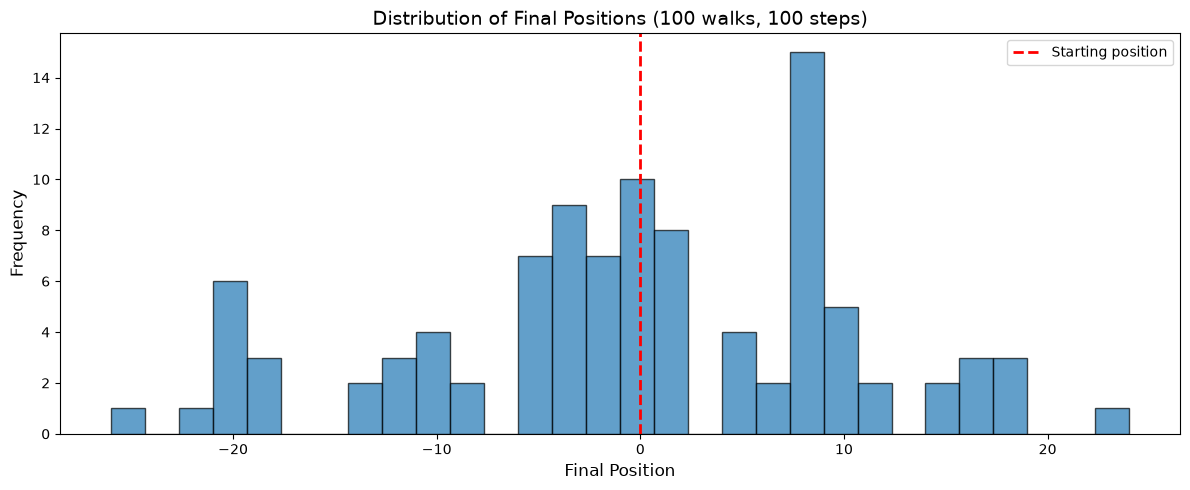


Statistics:
Mean final position: -0.42
Standard deviation: 10.45
Min: -26
Max: 24


In [3]:
def multiple_walks(num_walks, steps):
    """
    Run many random walks and visualize them all.
    """
    plt.figure(figsize=(14, 6))
    
    final_positions = []
    
    for i in range(num_walks):
        walk = random_walk_1d(steps)
        plt.plot(walk, alpha=0.3, linewidth=0.5)
        final_positions.append(walk[-1])
    
    plt.xlabel('Step Number', fontsize=12)
    plt.ylabel('Position', fontsize=12)
    plt.title(f'{num_walks} Random Walks', fontsize=14)
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Histogram of final positions
    plt.figure(figsize=(12, 5))
    plt.hist(final_positions, bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel('Final Position', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title(f'Distribution of Final Positions ({num_walks} walks, {steps} steps)', fontsize=14)
    plt.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Starting position')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return final_positions

# Explore!
finals = multiple_walks(100, 100)

print(f"\nStatistics:")
print(f"Mean final position: {np.mean(finals):.2f}")
print(f"Standard deviation: {np.std(finals):.2f}")
print(f"Min: {min(finals)}")
print(f"Max: {max(finals)}")

### What Do You Notice?

Look at the histogram. What shape does it have? Does it remind you of anything?

<details>
<summary>Reveal the secret</summary>

It's a **bell curve** (normal distribution)! Even though each step is completely random, the final positions follow this beautiful symmetric pattern.

This is one of the most profound discoveries in probability theory: random processes often produce normal distributions.
</details>

### Investigation Time

Answer these by running experiments:

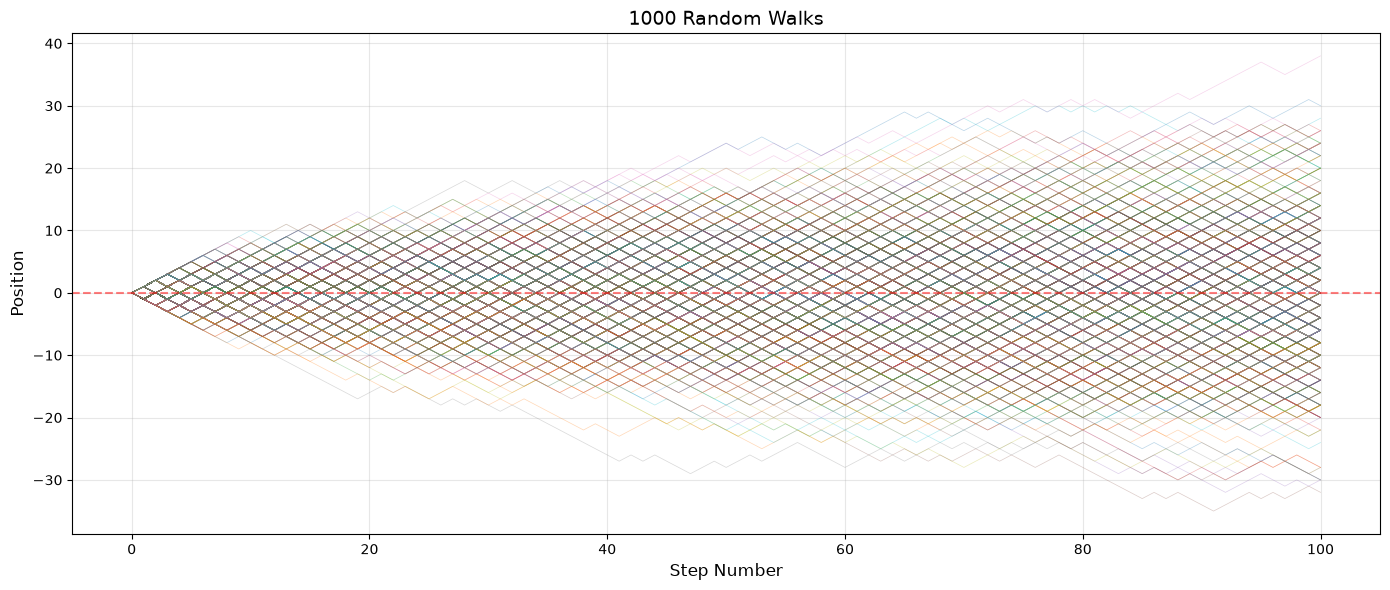

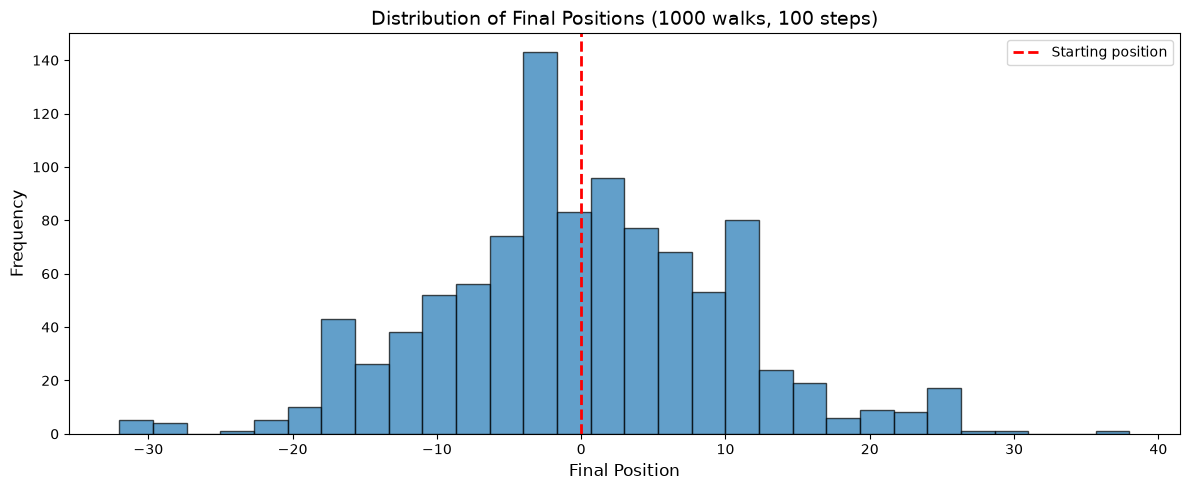

With 1000 walks: mean = -0.19


In [4]:
# 1. What happens with MORE walks but the SAME number of steps?
finals_1000 = multiple_walks(1000, 100)
print(f"With 1000 walks: mean = {np.mean(finals_1000):.2f}")

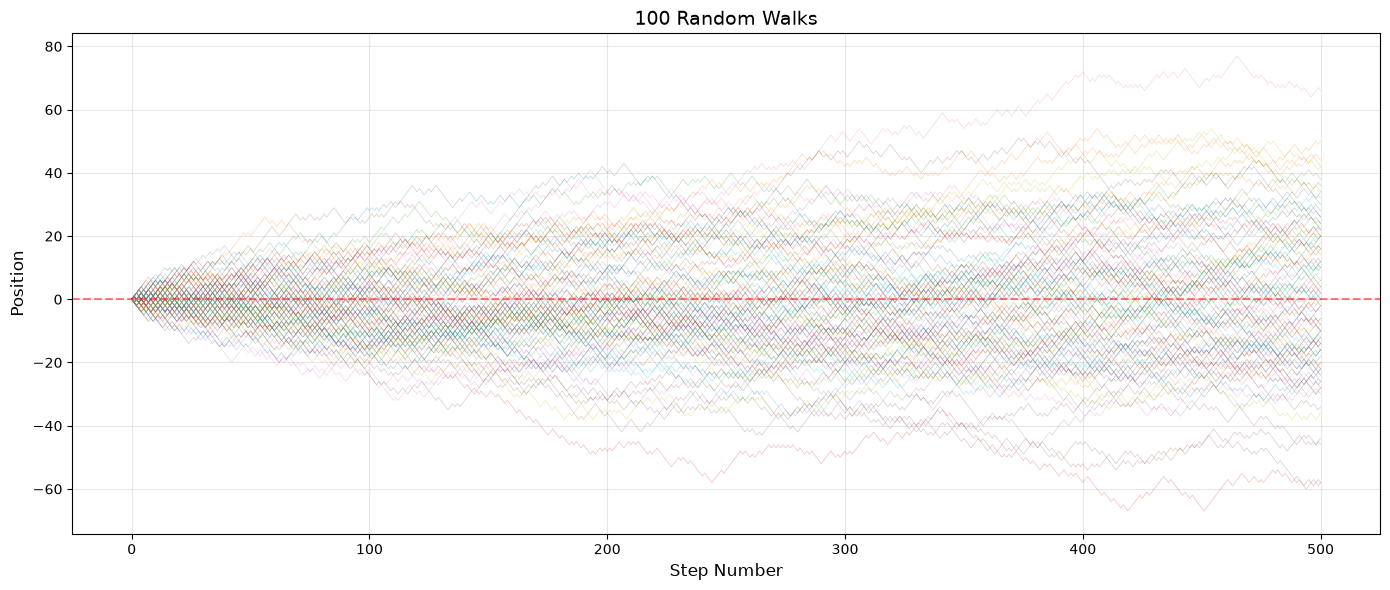

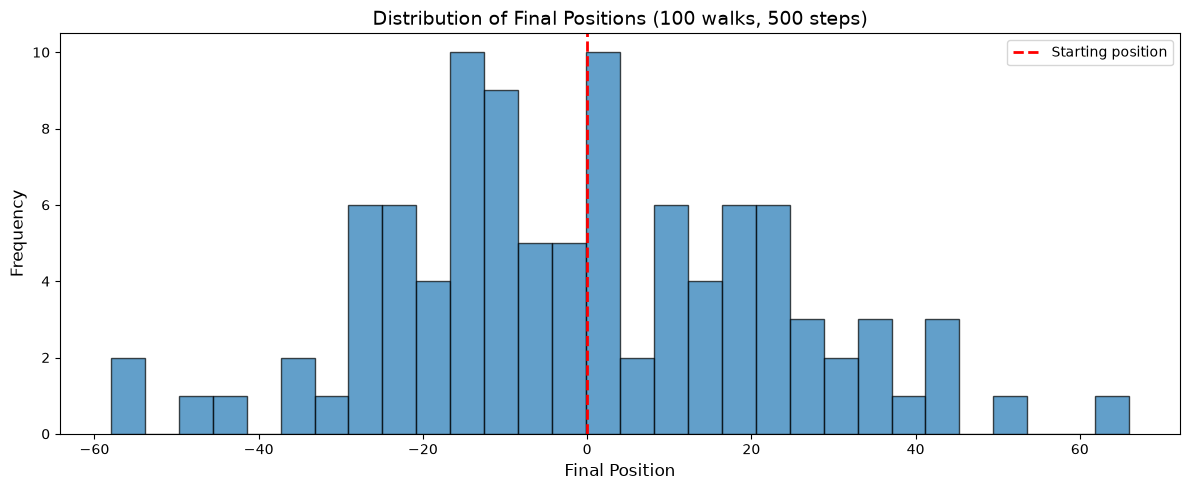

With 500 steps: spread (std) = 23.55


In [5]:
# 2. What happens with MORE steps but the SAME number of walks?
finals_500steps = multiple_walks(100, 500)
print(f"With 500 steps: spread (std) = {np.std(finals_500steps):.2f}")

**Key Insight:** The mean stays near 0 (why?), but the spread increases with more steps (why?).

Think about these before continuing!

---

## Part 3: From Random Walks to Weather

Let's shift gears. Instead of position, let's think about **states**: Sunny, Cloudy, or Rainy.

Here's real weather data for 15 days:

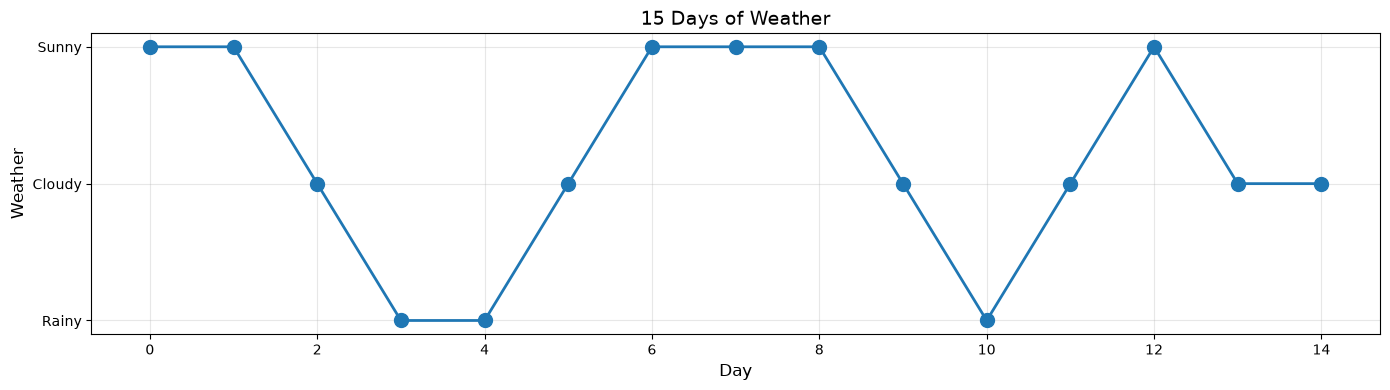


Weather sequence:
Day  1: Sunny
Day  2: Sunny
Day  3: Cloudy
Day  4: Rainy
Day  5: Rainy
Day  6: Cloudy
Day  7: Sunny
Day  8: Sunny
Day  9: Sunny
Day 10: Cloudy
Day 11: Rainy
Day 12: Cloudy
Day 13: Sunny
Day 14: Cloudy
Day 15: Cloudy


In [6]:
weather_sequence = ['Sunny', 'Sunny', 'Cloudy', 'Rainy', 'Rainy', 
                   'Cloudy', 'Sunny', 'Sunny', 'Sunny', 'Cloudy',
                   'Rainy', 'Cloudy', 'Sunny', 'Cloudy', 'Cloudy']

# Let's visualize it
weather_to_num = {'Sunny': 2, 'Cloudy': 1, 'Rainy': 0}
weather_nums = [weather_to_num[w] for w in weather_sequence]

plt.figure(figsize=(14, 4))
plt.plot(weather_nums, marker='o', markersize=10, linewidth=2)
plt.yticks([0, 1, 2], ['Rainy', 'Cloudy', 'Sunny'])
plt.xlabel('Day', fontsize=12)
plt.ylabel('Weather', fontsize=12)
plt.title('15 Days of Weather', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nWeather sequence:")
for i, weather in enumerate(weather_sequence, 1):
    print(f"Day {i:2d}: {weather}")

### The Key Question

If it's sunny today, what's the probability it will be sunny tomorrow?

This is different from asking: "What's the probability of a sunny day?"

**Why?** Because we're conditioning on what happened today. The future depends on the present!

This is called **conditional probability**.

### Counting Transitions

Let's count what happens after each type of day:

In [7]:
def count_transitions(sequence):
    """
    Count all transitions: Sunny->Sunny, Sunny->Cloudy, etc.
    """
    transitions = {}
    
    for i in range(len(sequence) - 1):
        current = sequence[i]
        next_state = sequence[i + 1]
        
        # Create key for this transition
        key = f"{current} -> {next_state}"
        
        if key not in transitions:
            transitions[key] = 0
        transitions[key] += 1
    
    return transitions

transitions = count_transitions(weather_sequence)

print("Transition counts:")
for transition, count in sorted(transitions.items()):
    print(f"{transition}: {count}")

Transition counts:
Cloudy -> Cloudy: 1
Cloudy -> Rainy: 2
Cloudy -> Sunny: 2
Rainy -> Cloudy: 2
Rainy -> Rainy: 1
Sunny -> Cloudy: 3
Sunny -> Sunny: 3


### From Counts to Probabilities

Now let's convert these counts into probabilities:

In [8]:
def calculate_transition_probabilities(sequence):
    """
    Calculate conditional probabilities: P(tomorrow | today)
    """
    # Get all unique states
    states = list(set(sequence))
    
    # Count transitions from each state
    transition_counts = {state: {} for state in states}
    
    for i in range(len(sequence) - 1):
        current = sequence[i]
        next_state = sequence[i + 1]
        
        if next_state not in transition_counts[current]:
            transition_counts[current][next_state] = 0
        transition_counts[current][next_state] += 1
    
    # Convert counts to probabilities
    transition_probs = {state: {} for state in states}
    
    for state in states:
        total = sum(transition_counts[state].values())
        for next_state, count in transition_counts[state].items():
            transition_probs[state][next_state] = count / total
    
    return transition_probs

probs = calculate_transition_probabilities(weather_sequence)

print("\nTransition Probabilities:")
print("=" * 40)
for state in sorted(probs.keys()):
    print(f"\nFrom {state}:")
    for next_state in sorted(probs[state].keys()):
        prob = probs[state][next_state]
        print(f"  to {next_state}: {prob:.3f} ({prob*100:.1f}%)")


Transition Probabilities:

From Cloudy:
  to Cloudy: 0.200 (20.0%)
  to Rainy: 0.400 (40.0%)
  to Sunny: 0.400 (40.0%)

From Rainy:
  to Cloudy: 0.667 (66.7%)
  to Rainy: 0.333 (33.3%)

From Sunny:
  to Cloudy: 0.500 (50.0%)
  to Sunny: 0.500 (50.0%)


### Answer the Original Question

Now we can answer: **If it's sunny today, what's the probability it will be sunny tomorrow?**

Look at the output above. Did you find it?

### Visual Representation

In [9]:
def visualize_transitions(probs):
    """
    Create a visual diagram of transitions.
    """
    states = sorted(probs.keys())
    
    print("\nTransition Diagram:")
    print("=" * 50)
    
    for current_state in states:
        print(f"\n{current_state:^20}")
        for next_state in states:
            if next_state in probs[current_state]:
                prob = probs[current_state][next_state]
                bar_length = int(prob * 30)
                bar = "█" * bar_length
                print(f"  → {next_state:10} {bar} {prob:.2f}")

visualize_transitions(probs)


Transition Diagram:

       Cloudy       
  → Cloudy     ██████ 0.20
  → Rainy      ████████████ 0.40
  → Sunny      ████████████ 0.40

       Rainy        
  → Cloudy     ████████████████████ 0.67
  → Rainy      ██████████ 0.33

       Sunny        
  → Cloudy     ███████████████ 0.50
  → Sunny      ███████████████ 0.50


---

## Part 4: Testing the Markov Property

Here's a crucial question: **Does the weather two days ago matter?**

In other words:
- Is P(tomorrow | today) different from P(tomorrow | today AND yesterday)?
- Does history beyond today matter?

If only today matters, we call this the **Markov property**: the future depends only on the present, not the past.

Let's test it!

In [10]:
def analyze_two_day_patterns(sequence):
    """
    Look at two-day patterns: (yesterday, today) -> tomorrow
    """
    patterns = {}
    
    for i in range(len(sequence) - 2):
        yesterday = sequence[i]
        today = sequence[i + 1]
        tomorrow = sequence[i + 2]
        
        key = f"({yesterday}, {today}) -> {tomorrow}"
        
        if key not in patterns:
            patterns[key] = 0
        patterns[key] += 1
    
    print("Two-day pattern analysis:")
    print("=" * 50)
    for pattern, count in sorted(patterns.items()):
        print(f"{pattern}: {count}")

analyze_two_day_patterns(weather_sequence)

Two-day pattern analysis:
(Cloudy, Rainy) -> Cloudy: 1
(Cloudy, Rainy) -> Rainy: 1
(Cloudy, Sunny) -> Cloudy: 1
(Cloudy, Sunny) -> Sunny: 1
(Rainy, Cloudy) -> Sunny: 2
(Rainy, Rainy) -> Cloudy: 1
(Sunny, Cloudy) -> Cloudy: 1
(Sunny, Cloudy) -> Rainy: 2
(Sunny, Sunny) -> Cloudy: 2
(Sunny, Sunny) -> Sunny: 1


**Question for you:** With this small dataset, can you tell if yesterday's weather matters?

We'd need more data to be sure. But for now, let's **assume** the Markov property holds: only today matters.

This simplification is incredibly powerful and is the foundation of Markov chains!

---

## Part 5: Building a Simple Predictor

Now that we have transition probabilities, let's build a weather predictor:

In [11]:
def predict_next_day(current_weather, transition_probs):
    """
    Predict tomorrow's weather based on today.
    Returns the most likely outcome.
    """
    if current_weather not in transition_probs:
        return "Unknown"
    
    possibilities = transition_probs[current_weather]
    
    # Find the most likely next state
    best_next = max(possibilities.items(), key=lambda x: x[1])
    
    return best_next[0], best_next[1]

# Test it
today = "Sunny"
prediction, probability = predict_next_day(today, probs)
print(f"If today is {today}:")
print(f"Tomorrow will most likely be: {prediction}")
print(f"Probability: {probability:.1%}")

print("\n" + "="*50)

# Try all states
for weather in ['Sunny', 'Cloudy', 'Rainy']:
    if weather in probs:
        pred, prob = predict_next_day(weather, probs)
        print(f"{weather:10} → {pred:10} ({prob:.1%})")

If today is Sunny:
Tomorrow will most likely be: Sunny
Probability: 50.0%

Sunny      → Sunny      (50.0%)
Cloudy     → Rainy      (40.0%)
Rainy      → Cloudy     (66.7%)


### But Wait - This Isn't How Weather Works!

Our predictor always gives the same answer. But real weather is probabilistic!

Let's make it more realistic:

In [12]:
def predict_probabilistic(current_weather, transition_probs):
    """
    Randomly choose next weather based on probabilities.
    This is how it ACTUALLY works!
    """
    if current_weather not in transition_probs:
        return "Unknown"
    
    possibilities = transition_probs[current_weather]
    
    # Get states and their probabilities
    states = list(possibilities.keys())
    probabilities = list(possibilities.values())
    
    # Randomly choose based on probabilities
    next_weather = np.random.choice(states, p=probabilities)
    
    return next_weather

# Simulate 10 days starting from Sunny
print("10-day probabilistic forecast starting from Sunny:\n")
current = "Sunny"
forecast = [current]

for day in range(10):
    next_weather = predict_probabilistic(current, probs)
    forecast.append(next_weather)
    current = next_weather

for i, weather in enumerate(forecast):
    print(f"Day {i:2d}: {weather}")

10-day probabilistic forecast starting from Sunny:

Day  0: Sunny
Day  1: Sunny
Day  2: Sunny
Day  3: Sunny
Day  4: Cloudy
Day  5: Sunny
Day  6: Sunny
Day  7: Cloudy
Day  8: Sunny
Day  9: Sunny
Day 10: Sunny


**Run the cell above multiple times.** Notice how you get different sequences each time, but they all seem reasonable given our probabilities.

**You just built a Markov chain simulator!** 🎉

Well, a simple one. But the core idea is there.

---

## Part 6: Mini-Project - Weather Prediction Game

Let's make this interactive! Can you beat the predictor?

In [13]:
def weather_game(actual_sequence, transition_probs, start_day=0, num_days=5):
    """
    Predict the next N days of weather.
    Compare your predictions to the actual sequence.
    """
    print("Weather Prediction Game!")
    print("=" * 50)
    print(f"Starting weather: {actual_sequence[start_day]}\n")
    
    # Show what we know
    print("Transition probabilities:")
    for state in sorted(transition_probs.keys()):
        print(f"  {state}: {transition_probs[state]}")
    
    print("\n" + "="*50)
    
    # Make predictions
    model_score = 0
    current = actual_sequence[start_day]
    
    for day in range(1, num_days + 1):
        if start_day + day >= len(actual_sequence):
            print("\nRan out of actual data!")
            break
        
        # What actually happened
        actual = actual_sequence[start_day + day]
        
        # What would the model predict (most likely)
        model_prediction, confidence = predict_next_day(current, transition_probs)
        
        print(f"\nDay {day}:")
        print(f"  Previous: {current}")
        print(f"  Model predicts: {model_prediction} ({confidence:.1%} confidence)")
        print(f"  Actually was: {actual}")
        
        if model_prediction == actual:
            print("  ✓ Model was correct!")
            model_score += 1
        else:
            print("  ✗ Model was wrong")
        
        current = actual
    
    print("\n" + "="*50)
    print(f"Model score: {model_score}/{num_days} ({model_score/num_days:.1%})")

# Play the game!
weather_game(weather_sequence, probs, start_day=0, num_days=5)

Weather Prediction Game!
Starting weather: Sunny

Transition probabilities:
  Cloudy: {'Rainy': 0.4, 'Sunny': 0.4, 'Cloudy': 0.2}
  Rainy: {'Rainy': 0.3333333333333333, 'Cloudy': 0.6666666666666666}
  Sunny: {'Sunny': 0.5, 'Cloudy': 0.5}


Day 1:
  Previous: Sunny
  Model predicts: Sunny (50.0% confidence)
  Actually was: Sunny
  ✓ Model was correct!

Day 2:
  Previous: Sunny
  Model predicts: Sunny (50.0% confidence)
  Actually was: Cloudy
  ✗ Model was wrong

Day 3:
  Previous: Cloudy
  Model predicts: Rainy (40.0% confidence)
  Actually was: Rainy
  ✓ Model was correct!

Day 4:
  Previous: Rainy
  Model predicts: Cloudy (66.7% confidence)
  Actually was: Rainy
  ✗ Model was wrong

Day 5:
  Previous: Rainy
  Model predicts: Cloudy (66.7% confidence)
  Actually was: Cloudy
  ✓ Model was correct!

Model score: 3/5 (60.0%)


### Reflection Questions

1. How well did the model do?
2. Could you have done better by hand?
3. What makes weather prediction hard?
4. With more data, would the model improve?

---

## Week 1-2 Summary

You've discovered some profound ideas:

### 🎲 About Randomness
- Individual random events are unpredictable
- But patterns emerge in aggregates
- Random walks produce normal distributions

### 🌦️ About Probability
- **Conditional probability**: P(tomorrow | today)
- The future can depend on the present
- We can quantify uncertainty with numbers

### 🔗 About Markov Chains (Preview!)
- **Markov property**: Only the present state matters
- **Transition probabilities**: Likelihood of moving between states
- **State space**: The set of possible situations (Sunny, Cloudy, Rainy)

### 💻 About Simulation
- We can model real-world randomness in code
- Simulations help us understand probability
- More trials → More reliable estimates

---

## Looking Ahead: Week 3-4

Next, we'll discover a powerful tool for organizing all these transition probabilities: **matrices**!

Instead of nested dictionaries, we'll represent our weather transitions as a grid of numbers. And matrix multiplication will let us predict not just tomorrow, but many days into the future.

We're building toward the full Markov chain framework, one concept at a time.

---

## Challenge Problems

### Challenge 1: Multiple Starting Points
Modify the `multiple_walks` function to start some walks at position 0, some at +10, and some at -10. What happens to the distributions?

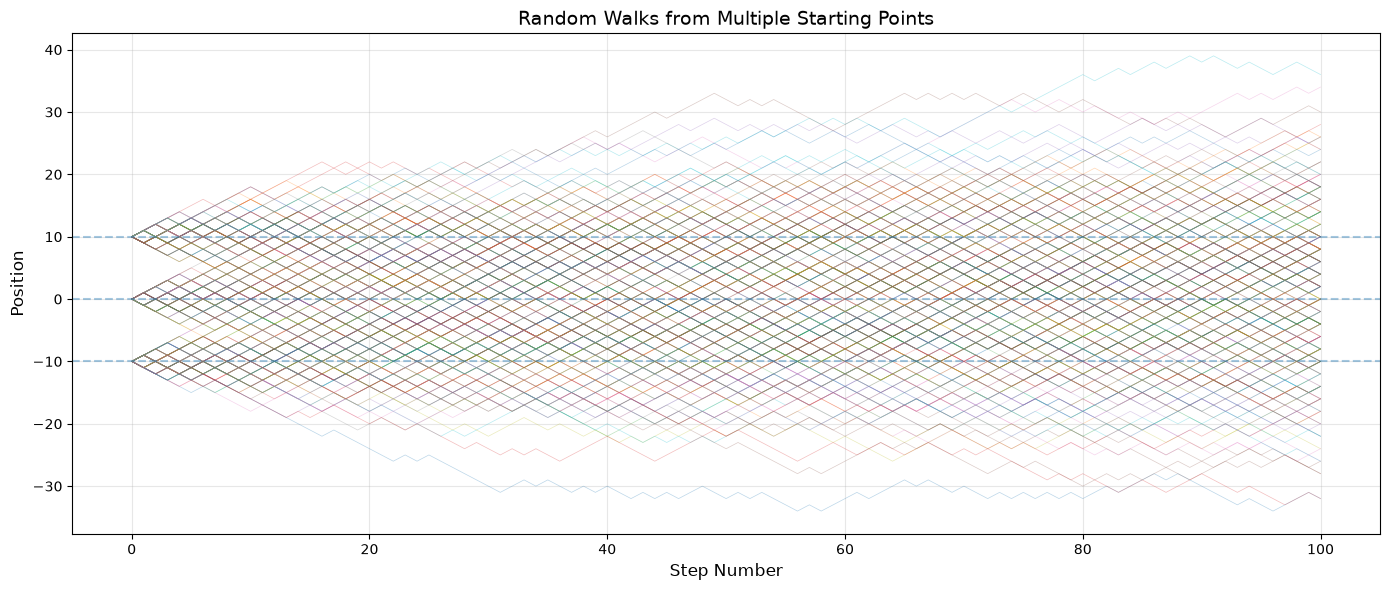

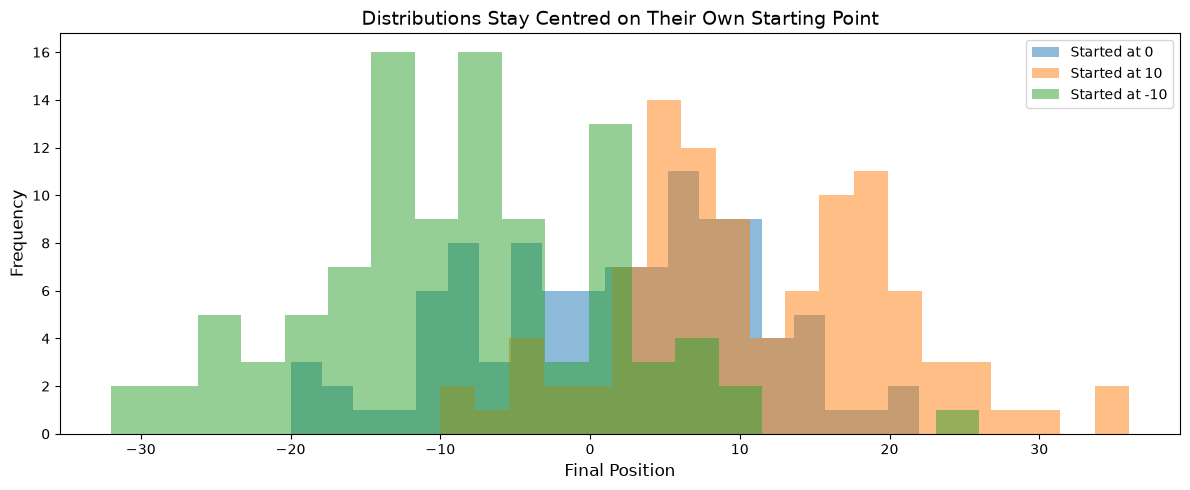

Started at 0: mean final position = 1.62
Started at 10: mean final position = 11.20
Started at -10: mean final position = -8.74


In [14]:
# Your code here
def multiple_walks_from_starts(num_walks_per_start, steps, starts=(0, 10, -10)):
    """
    Run random walks from several different starting points and compare
    where they end up.
    """
    plt.figure(figsize=(14, 6))

    final_positions = {start: [] for start in starts}

    for start in starts:
        for _ in range(num_walks_per_start):
            walk = random_walk_1d(steps)
            walk = [start + p for p in walk]  # shift the whole walk to this start
            plt.plot(walk, alpha=0.3, linewidth=0.5)
            final_positions[start].append(walk[-1])

    plt.xlabel('Step Number', fontsize=12)
    plt.ylabel('Position', fontsize=12)
    plt.title(f'Random Walks from Multiple Starting Points', fontsize=14)
    for start in starts:
        plt.axhline(y=start, linestyle='--', alpha=0.4)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    for start in starts:
        plt.hist(final_positions[start], bins=20, alpha=0.5, label=f'Started at {start}')
    plt.xlabel('Final Position', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Distributions Stay Centred on Their Own Starting Point', fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return final_positions

results = multiple_walks_from_starts(100, 100)
for start, finals in results.items():
    print(f"Started at {start}: mean final position = {np.mean(finals):.2f}")


### Challenge 2: 2D Random Walk
Create a random walk on a 2D grid. At each step, move North, South, East, or West randomly. Visualize the path using `plt.plot()`.

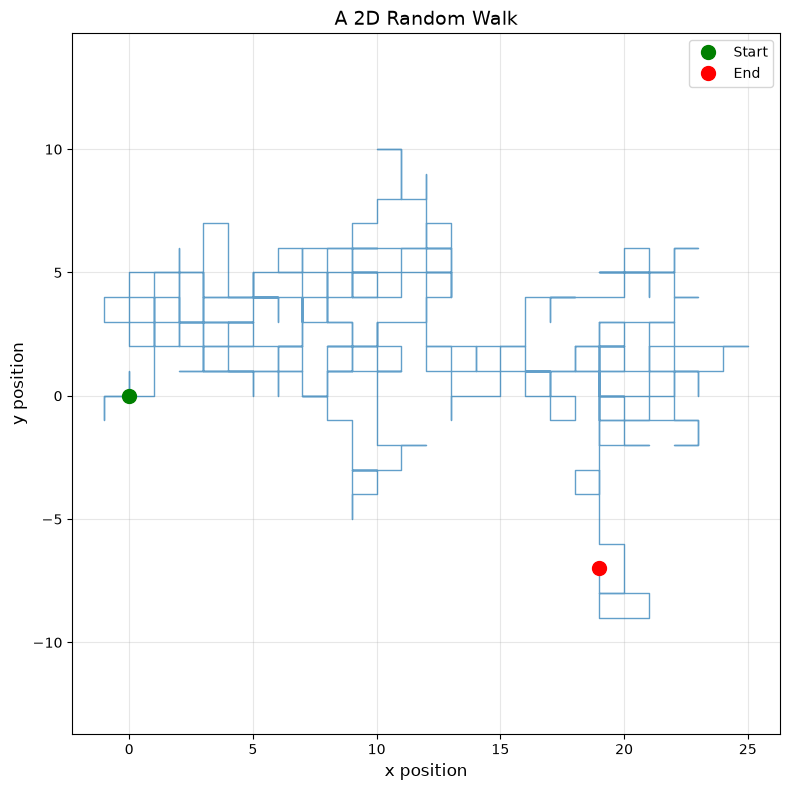

Ended at: (19, -7)


In [15]:
# Hint: Keep track of (x, y) position
def random_walk_2d(steps):
    """A random walk on a 2D grid: each step moves N, S, E, or W."""
    x, y = 0, 0
    xs, ys = [x], [y]

    moves = [(0, 1), (0, -1), (1, 0), (-1, 0)]  # N, S, E, W

    for _ in range(steps):
        dx, dy = moves[np.random.randint(len(moves))]
        x += dx
        y += dy
        xs.append(x)
        ys.append(y)

    return xs, ys

xs, ys = random_walk_2d(500)

plt.figure(figsize=(8, 8))
plt.plot(xs, ys, linewidth=1, alpha=0.7)
plt.plot(xs[0], ys[0], 'go', markersize=10, label='Start')
plt.plot(xs[-1], ys[-1], 'ro', markersize=10, label='End')
plt.xlabel('x position', fontsize=12)
plt.ylabel('y position', fontsize=12)
plt.title('A 2D Random Walk', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

print(f"Ended at: ({xs[-1]}, {ys[-1]})")


### Challenge 3: More Weather States
Add two more weather states: 'Stormy' and 'Foggy'. Generate a fake dataset with transitions between all 5 states. Calculate the transition probabilities.

In [16]:
# Create your extended weather model
extended_weather_sequence = ['Sunny', 'Sunny', 'Cloudy', 'Rainy', 'Stormy',
                              'Rainy', 'Cloudy', 'Foggy', 'Foggy', 'Sunny',
                              'Sunny', 'Cloudy', 'Rainy', 'Stormy', 'Stormy',
                              'Rainy', 'Cloudy', 'Foggy', 'Sunny', 'Sunny',
                              'Cloudy', 'Rainy', 'Rainy', 'Cloudy', 'Foggy']

extended_probs = calculate_transition_probabilities(extended_weather_sequence)

print("Transition Probabilities (5 states):")
print("=" * 40)
for state in sorted(extended_probs.keys()):
    print(f"\nFrom {state}:")
    for next_state in sorted(extended_probs[state].keys()):
        prob = extended_probs[state][next_state]
        print(f"  to {next_state}: {prob:.3f} ({prob*100:.1f}%)")


Transition Probabilities (5 states):

From Cloudy:
  to Foggy: 0.500 (50.0%)
  to Rainy: 0.500 (50.0%)

From Foggy:
  to Foggy: 0.333 (33.3%)
  to Sunny: 0.667 (66.7%)

From Rainy:
  to Cloudy: 0.500 (50.0%)
  to Rainy: 0.167 (16.7%)
  to Stormy: 0.333 (33.3%)

From Stormy:
  to Rainy: 0.667 (66.7%)
  to Stormy: 0.333 (33.3%)

From Sunny:
  to Cloudy: 0.500 (50.0%)
  to Sunny: 0.500 (50.0%)


### Challenge 4: Does The Model Work?
Create a longer weather sequence (30+ days). Use the first 20 days to build your model, then test it on the remaining days. Calculate the prediction accuracy.

In [17]:
# Train/test split for weather prediction
long_weather_sequence = (['Sunny', 'Sunny', 'Cloudy', 'Rainy', 'Rainy',
                          'Cloudy', 'Sunny', 'Sunny', 'Sunny', 'Cloudy',
                          'Rainy', 'Cloudy', 'Sunny', 'Cloudy', 'Cloudy'] * 3)[:32]

train_days = long_weather_sequence[:20]
test_days = long_weather_sequence[20:]

train_probs = calculate_transition_probabilities(train_days)

correct = 0
total = 0
for i in range(len(test_days) - 1):
    current = test_days[i]
    actual_next = test_days[i + 1]

    if current not in train_probs:
        continue

    predicted_next, _ = predict_next_day(current, train_probs)
    total += 1
    if predicted_next == actual_next:
        correct += 1

print(f"Trained on {len(train_days)} days, tested on {len(test_days)} days.")
print(f"Prediction accuracy: {correct}/{total} ({correct/total:.1%})")


Trained on 20 days, tested on 12 days.
Prediction accuracy: 4/11 (36.4%)
